In [ ]:
from itertools import combinations
from collections import defaultdict
from music21 import stream, note, chord, interval, expressions, articulations
from sonority_Klassifier import klingende_Noten_im_Bereich
from Notenbearbeitung import Grenzen_aller_Elemente, Noten_am_Offset, Sammlung_aller_Slice,notes_in_time_span
from Notenbearbeitung import weglassen_doppelte_Noten,weglassen_doppelte_Noten_bei_Figurierung,ist_Konsonantes_Intervall
from Klang import Beurteilung_dissonanten_Klangs,Bezifferung_Generalbass,Bezifferung_Auflösungsklangs,Bestimmung_der_Zielnote,Beurteilung_dissonanten_Klangs2
from Klang import Intervalls_von_Basston_im_Akkord,finden_Note_über_Bass,Wie_ein_Klang_aufgelöst,ist_Ein_Septakkord
from Klang import HarmonischerRhythmusKontext
from Modus import Modi_auf_der_Hiflsstimme
from Dissonanzanalyse import Einfache_Analyse
from Markierung import note_am_dissonanzbeginn

# Konsonanzen-Menge (Sonderfall: reine Quarte über dem Bass zählt als Dissonanz)
KONSONANZEN = {'P1', 'm3', 'M3', 'P5', 'm6', 'M6', 'P8'}
    
#补充逻辑：在unbezifferter Aannotationsmodus中，如果不协和音程的两个音相对于Annotationston都是协和音，补充方法
#


def Ausschnitte_inHilfsstimme_beiZeit(Ausschnitte_inHilfsstimme, t):
    """Gibt das Segment zurück, das bei Zeit t aktiv ist (t ∈ [Anfang, Ende))."""
    for Ausschnitt in Ausschnitte_inHilfsstimme:
        if Ausschnitt['Anfang'] <= t < Ausschnitt['Ende']:
            return Ausschnitt
    return None

Q = lambda x: round(float(x), 6)


def reduced_interval_name(iv, max_degree=10):
    """
    Nimmt ein music21.interval.Interval und gibt den Namen mit max. 15 Stufen zurück.
    z.B. M17 -> M10, P29 -> P15
    """
    deg = iv.generic.undirected
    while deg > max_degree:
        deg -= 7  # reduziere um Oktaven
    simple = iv.simpleName
    quality = simple[0]    # M, m, P, A, d
    return f"{quality}{deg}"


def Dissonanzanalyse_für_konsonanten_Klang(Töne_am_Offset, Annotationston, Original_Slices, Modus=None):
    Dissonanzen = []
    SliceBass = min(Töne_am_Offset, key=lambda n: n.pitch.midi)

    # Zuerst nur dissonante Intervalle innerhalb des Original-Slices finden.
    for n, n2 in combinations(Töne_am_Offset, 2):
        if ist_Konsonantes_Intervall(n, n2, SliceBass):
            continue
        
        # Erst danach beide Intervalltöne mit dem Annotationston vergleichen.
        Konsonant_zwischen_Annotationston_n = ist_Konsonantes_Intervall(n, Annotationston)
        Konsonant_zwischen_Annotationston_n2 = ist_Konsonantes_Intervall(n2, Annotationston)

        if Konsonant_zwischen_Annotationston_n != Konsonant_zwischen_Annotationston_n2:
            if Konsonant_zwischen_Annotationston_n:
                Dissonanz = n2
                PartnerTon = Annotationston
            else:
                Dissonanz = n
                PartnerTon = Annotationston
        else:
            Dissonanz = Einfache_Analyse(n, n2, Original_Slices)
            PartnerTon = n2 if Dissonanz is n else n
        Dissonanzen.append({'Dissonanz': Dissonanz, 'Partnerton': PartnerTon})
    return Dissonanzen

def Dissonanzanalyse_vom_Bass_nach_oben(n,Bass,Gerüstklang,wesentliche_Dissonanz=None):
    Partnerton=None
    Intervall_über_Bass = interval.Interval(Bass, n)
    if not Intervall_über_Bass.isConsonant():
        Partnerton=Bass
    else:
        Gerüsttöne=Gerüstklang.notes
        for Gerüstton in Gerüsttöne:
            Intervall2 = interval.Interval(Gerüstton, n)
            if Gerüstton.nameWithOctave == Bass.nameWithOctave:
                continue 
            if Intervall2.isConsonant() or Intervall2.simpleName == 'P4':
                continue
            Partnerton=Gerüstton
    return  Partnerton
    

#def Dissonanz_und_Bass(Ton,Töne_am_Anfang,Bass):
    #überprüfung, ob ein Ton ein Dissonanz nicht im Bezug auf dem Bass ist.

def Dissonanzanalyse_für_dissonanten_Klang(Töne_am_Anfang,Klanggerüst,Akkordtonnamen,Akkorddissonanz,Original_Slices):
    Dissonanzen=[]
    Bass= note.Note(Klanggerüst.bass()) if Klanggerüst.bass() else None
    for a, b in combinations(Töne_am_Anfang, 2):
        Unterer, Oberer = (a, b) if a.pitch.midi <= b.pitch.midi else (b, a)
        ist_Konsonant=ist_Konsonantes_Intervall(a,b,Bass)
        a_Akk = getattr(a, 'name', None) in Akkordtonnamen 
        b_Akk = getattr(b, 'name', None) in Akkordtonnamen
        #print(a.Takt_Nr,a.offset_Takt,Akkordtonnamen)
        if ist_Konsonant:
            continue
        if a_Akk and b_Akk:
            if a.name in Akkorddissonanz or b.name in Akkorddissonanz:
                
                Dissonanz= a if a.name in Akkorddissonanz else b
                PartnerTon = b if Dissonanz is a else a
            elif a.name not in Akkorddissonanz and b.name not in Akkorddissonanz:
                Dissonanz= a if a is Unterer else b
                PartnerTon = b if Dissonanz is a else a
        elif (a_Akk and not b_Akk) or (b_Akk and not a_Akk):
            Dissonanz = a if b_Akk else b
            PartnerTon = b if Dissonanz is a else a
        elif not a_Akk and not b_Akk:
            Dissonanz = Bestimmung_der_Zielnote(a, b, Töne_am_Anfang,Original_Slices)
            PartnerTon = b if Dissonanz is a else a
        else:
            print(a.Takt_Nr,a.offset_Takt,'unbekannte Dissonanz:',a,b)
        #print(a.Takt_Nr,a.offset_Takt,a,b)
        Dissonanzen.append({'Dissonanz':Dissonanz,'Partnerton':PartnerTon})  
    return Dissonanzen

def zufällige_oder_wesentliche_Dissonanz(Akkord,Töne_im_Bereich):
    Akkord_enge_Lage = Akkord.closedPosition()
    Intervalle=Intervalls_von_Basston_im_Akkord(Akkord_enge_Lage)
    Intervallzahle =[i.generic.value for i in Intervalle]
    if Intervallzahle == [3,4]:
        Quarte = finden_Note_über_Bass(Akkord, 4)
        Wie_Auflösung = Wie_ein_Klang_aufgelöst("34",Töne_im_Bereich,None,None,Quarte)
        if Wie_Auflösung=="35":
            return 'Zufällige'
        elif Wie_Auflösung=="34":
            return 'Wesentliche'
    elif Intervallzahle == [2,6]:
        Sekunde = finden_Note_über_Bass(Akkord, 2)
        Wie_Auflösung = Wie_ein_Klang_aufgelöst("26",Töne_im_Bereich,None,Sekunde,None)
        if Wie_Auflösung=="6":
            return 'Zufällige'
        elif Wie_Auflösung=="26":
            return 'Wesentliche'
    else:
        return 'nichts'

def Dissonanzanalyse(score: stream.Score, Auftakt,hilfsstimme_index: int = -1, 
                     debug: bool = False, nur_kandidaten: bool = False,
                     lookback_quarters: float | None = None):
    
    Dissonanzen_Kandidaten = defaultdict(list)

    Stimmen = list(score.parts)
    Hilfsstimme = Stimmen[hilfsstimme_index] if Stimmen else None
    Originalstimmen = [st for st in Stimmen if st is not Hilfsstimme]
    Originalstream = stream.Stream()  # stream.Part() / stream.Stream()
    for part in Originalstimmen:
        for el in part.flatten().notesAndRests:
            Originalstream.insert(el.offset, el)

    Grenzen = Grenzen_aller_Elemente(score)

    score_slices = Sammlung_aller_Slice(score, Grenzen,Auftakt)
    hs_slices    = Sammlung_aller_Slice(Hilfsstimme, Grenzen,Auftakt)
    Original_Slices = Sammlung_aller_Slice(Originalstream, Grenzen,Auftakt)
    #print(Original_Slices)
    DieHilfsstimme = Modi_auf_der_Hiflsstimme(score,Grenzen,Original_Slices,hilfsstimme_index)
    Einzele_Stimme_slices = {}
    for i, p in enumerate(Stimmen):
        if i == hilfsstimme_index:
            continue
        Einzele_Stimme_slices[i] = Sammlung_aller_Slice(p, Grenzen, Auftakt)
    cache_Originaltöne = {}
    Figuration_Akkorddissonanzen = {}
    Standard_Harmoniekontext = HarmonischerRhythmusKontext()
    
    Segment_bearbeitet = False
    Aktuelles_Segment = None
    
    for i in range(len(Grenzen) - 1):
        Anfang, Ende = float(Grenzen[i]), float(Grenzen[i + 1])
        if Ende <= Anfang:
            continue
        Töne_am_Anfang = Noten_am_Offset(Original_Slices, Anfang)

        if not Töne_am_Anfang or len(Töne_am_Anfang) < 2:
            continue
        
        Alle_Töne_am_Offset=Noten_am_Offset(score_slices, Anfang) # für Zweck der Überprüfung
        for n in Alle_Töne_am_Offset:
            if n.isNote:
                #print(n.Takt_Nr,n.offset_Takt)
                break
        #print(Töne_am_Anfang,Anfang)
        
        
        Bass_slice = min(Töne_am_Anfang, key=lambda n: n.pitch.midi) 
        Ausschnitt = Ausschnitte_inHilfsstimme_beiZeit(DieHilfsstimme, Anfang)
        #print(Anfang)
        
        Modus = Ausschnitt.get('Modus') if Ausschnitt is not None else None
        if Modus != 'Standard':
            Standard_Harmoniekontext.zurücksetzen()
            Anfang_Modus, Ende_Modus = float(Ausschnitt['Anfang']), float(Ausschnitt['Ende'])
            HarmonieAnfang = Anfang_Modus
            Kennzeichen=Ausschnitt.get('Kennzeichen')
            Annotationston = Ausschnitt.get('Annotationston', None)
            PartnerTon=Ausschnitt.get('Partnerton')
            key = (Anfang_Modus, Ende_Modus)
            if key not in cache_Originaltöne:
                cache_Originaltöne[key] = notes_in_time_span(Original_Slices, Anfang_Modus, Ende_Modus)
            Töne_im_Bereich = cache_Originaltöne[key]
            #print(Anfang,Töne_im_Bereich)
            Töne_im_Bereich_0 = list(cache_Originaltöne[key])
            #print([n.nameWithOctave for n in Töne_im_Bereich_0])
            Dissonanzen = []
            if 'Of' in Kennzeichen:    
                Töne_am_Anfang = weglassen_doppelte_Noten_bei_Figurierung(Töne_am_Anfang)
                Alle_Töne_am_Offset = weglassen_doppelte_Noten_bei_Figurierung(Alle_Töne_am_Offset)
                Töne_im_Bereich = weglassen_doppelte_Noten_bei_Figurierung(Töne_im_Bereich)
                Töne_im_Bereich_0 = weglassen_doppelte_Noten_bei_Figurierung(Töne_im_Bereich_0)
            elif 'O' in Kennzeichen:
                Töne_am_Anfang = weglassen_doppelte_Noten(Töne_am_Anfang,modus="offset")
                Alle_Töne_am_Offset = weglassen_doppelte_Noten(Alle_Töne_am_Offset,modus="offset")
                Töne_im_Bereich = weglassen_doppelte_Noten(Töne_im_Bereich,modus="Bereich")
                Töne_im_Bereich_0 = weglassen_doppelte_Noten(Töne_im_Bereich_0,modus="Bereich")
            if 'P' in Kennzeichen:
                Töne_am_Anfang = {n for n in Töne_am_Anfang if n.nameWithOctave != Annotationston.nameWithOctave}
                Alle_Töne_am_Offset = {n for n in Alle_Töne_am_Offset if n.nameWithOctave != Annotationston.nameWithOctave}
                Töne_im_Bereich = {n for n in Töne_im_Bereich if n.nameWithOctave != Annotationston.nameWithOctave}
            if 'F' in Kennzeichen:
                Töne_am_Anfang.append(Annotationston)
                Töne_im_Bereich.append(Annotationston)
            # zuerst die Wiederholungsnote bearbeiten:

            if Modus == 'Figuration':
                segment_key = (Anfang_Modus, Ende_Modus)
                bearbeitete_akkorddissonanzen = Figuration_Akkorddissonanzen.setdefault(segment_key, set())
                Bass = min(Töne_am_Anfang, key=lambda n: n.pitch.midi)
                Annotationston = Ausschnitt.get('Annotationston')       
                Konsonanter_Klang= Ausschnitt.get('Qualität') 
                ist_Septakkord=Ausschnitt.get('Septakkord')
                Gerüstdissonanzname = set()
                if Konsonanter_Klang:
                    #print(Anfang_Modus,Annotationston)
                    Dissonanzen=Dissonanzanalyse_für_konsonanten_Klang(Töne_am_Anfang,Annotationston,Original_Slices,Modus=Modus)
                else:
                    zum_Akkord = Ausschnitt.get('Klang') 
                    Gerüsttöne = zum_Akkord.notes
                    Akkordtönenamen =  Ausschnitt.get('Akkordeigene_Töne')  
                    Akkorddissonanz_am_Anfang= Ausschnitt.get('Akkorddissonanz') 
                    assert all(n is not None for n in Akkorddissonanz_am_Anfang), f"Akkorddissonanz enthält None: Takt={getattr(Töne_am_Anfang[0], 'Takt_Nr', '?') if Töne_am_Anfang else '?'}, Offset={Anfang}, Figuration={Anfang_Modus}-{Ende_Modus}, Gerüsttöne={[n.nameWithOctave for n in zum_Akkord.notes]}, Akkorddissonanz={Akkorddissonanz_am_Anfang}"
                    Akkorddissonanznamen= [n.name for n in Akkorddissonanz_am_Anfang]
                    Gerüstdissonanzname = Akkorddissonanznamen 
                    if ist_Septakkord:
                        Dissonanzen=Dissonanzanalyse_für_dissonanten_Klang(Töne_am_Anfang,zum_Akkord,Akkordtönenamen,Akkorddissonanznamen,Original_Slices)
                    else:
                        Klangnamen = [n.name for n in Gerüsttöne]
                        übrige_Töne = [n for n in Töne_im_Bereich_0 if n.name not in Klangnamen]
                        for Grundton in übrige_Töne:
                            Klang_mit_Ton = chord.Chord((Grundton,) + Gerüsttöne)
                            Grundtonname = Klang_mit_Ton.root().name if Klang_mit_Ton.root() else None
                            if Grundton.name == Grundtonname:
                                parent = Grundton.getContextByClass(stream.Part)
                                Stimme_idx = next(
                                        (i for i, stimme in enumerate(Stimmen)
                                        if stimme.id == parent.id or str(stimme.id) + "_flat" == str(parent.id)),
                                        None
                                    )
                                #print(Grundton.Takt_Nr, Grundton, Stimme_idx)
                                Töne_in_Stimme= notes_in_time_span(Einzele_Stimme_slices.get(Stimme_idx, []), Anfang_Modus, Ende_Modus)
                                Septakkord=ist_Ein_Septakkord(Klang_mit_Ton,None,Töne_in_Stimme,Grundton.abs_offset)
                                if Septakkord :
                                    Akkordtönenamen.add(Grundton.name)
                                    break
                        Dissonanzen=Dissonanzanalyse_für_dissonanten_Klang(Töne_am_Anfang,zum_Akkord,Akkordtönenamen,Akkorddissonanznamen,Original_Slices)

                for Elemente in Dissonanzen:
                    Dissonanz = Elemente['Dissonanz']
                    PartnerTon = Elemente['Partnerton']
                    if Dissonanz.name in Gerüstdissonanzname:
                        dissonanz_key = (Dissonanz.nameWithOctave, Dissonanz.Takt_Nr)
                        if dissonanz_key in bearbeitete_akkorddissonanzen:
                            continue
                        bearbeitete_akkorddissonanzen.add(dissonanz_key)
                    reduced_name = reduced_interval_name(interval.Interval(Dissonanz, PartnerTon))
                    Unterer, Oberer = (Dissonanz, PartnerTon) if Dissonanz.pitch.midi <= PartnerTon.pitch.midi else (PartnerTon, Dissonanz)
                    Objekt =  Dissonanz.Chord_Objekt if Dissonanz.Chord_Objekt else Dissonanz
                    mit_bass = (Dissonanz is Bass_slice) or (PartnerTon is Bass_slice)
                    Halbtöne = abs(Dissonanz.pitch.midi - PartnerTon.pitch.midi)
                    Töne_bei_Dissonanz = Noten_am_Offset(Original_Slices, Dissonanz.abs_offset)
                    if not Dissonanz.duration.isGrace:
                        #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Dissonanz.name)
                        Töne_am_Anfang = [n for n in Töne_bei_Dissonanz if not n.duration.isGrace]
                        if len(Töne_am_Anfang) <= 2:
                            Generalbassbezifferung=reduced_interval_name(interval.Interval(Dissonanz, PartnerTon))
                        if len(Töne_am_Anfang) > 2:
                            zum_Akkord=chord.Chord(Töne_am_Anfang) 
                            Akkordinformation = Beurteilung_dissonanten_Klangs2(zum_Akkord,1,Anfang,Grenzen,Original_Slices,Kennzeichen) 
                            Generalbassbezifferung = Bezifferung_Generalbass(Akkordinformation,Dissonanz,reduced_name)
                            #den Auflösungsklang bearbeiten:
                        Dissonanzdauer = float(getattr(Dissonanz, 'quarterLength', 0.0))
                        Auflösungsoffset = Dissonanz.abs_offset + Dissonanzdauer
                        Generalbassbezifferung_2 = Bezifferung_Auflösungsklangs(Grenzen,score_slices,Kennzeichen,PartnerTon,Auflösungsoffset)
                    else:
                        Generalbassbezifferung=reduced_interval_name(interval.Interval(Dissonanz,PartnerTon))
                        Verzierungstöne_am_Anfang = [n for n in Töne_bei_Dissonanz if n.duration.isGrace]
                        if len(Verzierungstöne_am_Anfang)<2:
                            Generalbassbezifferung_2 = Bezifferung_Auflösungsklangs(Grenzen,score_slices,Kennzeichen,PartnerTon,Dissonanz.abs_offset)
                        else:
                            Generalbassbezifferung_2 ='?'
                    

                    Klangeigenschaft = f"{Generalbassbezifferung} - {Generalbassbezifferung_2}"

                    #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Töne_am_Anfang)
                    Dissonanzen_Kandidaten[Dissonanz].append({
                        'Intervall': Klangeigenschaft,
                        'PartnerTon': PartnerTon,
                        'Dissonanz_Offset':Dissonanz.abs_offset,
                        'mitBass': mit_bass,
                        'Anfang':Anfang,
                        'HarmonieAnfang': HarmonieAnfang,
                        'Halbtöne': Halbtöne,
                        'untererTon': Unterer,
                        'ObererTon': Oberer,
                        'Modus': Modus,
                        'SliceAnfang': Anfang_Modus,
                        'SliceEnde':Ende_Modus,
                        'SliceBass': Bass_slice,
                        'Objekt':Objekt
                    })
        
            elif Modus=='Alberti':
                Klanggerüst = Ausschnitt.get('Klanggerüst') #Chord.chord
                Akkord_am_Anfang = Ausschnitt.get('Töne_am_Anfang')
                Modusanfang = Ausschnitt.get('Anfang') 
                Kennzeichen = Ausschnitt.get('Kennzeichen') 
                Bass=Ausschnitt.get('Bass')
                Bassziffer=Ausschnitt.get('Zahl')
                Gerüsttönename=[n.name for n in Klanggerüst.notes]
                Gerüsttönegenauername=[n.nameWithOctave for n in Klanggerüst.notes]
                Dissonanzen = []
                Akkorddissonanzen=[]
                übrige_Töne = [n for n in Töne_im_Bereich_0 if n.name not in Gerüsttönename]
                Gerüsttöne = [n for n in Töne_im_Bereich_0 if n.nameWithOctave in Gerüsttönegenauername]
                Wesentliche_Dissonanz=None
                Wesentliche_Konsonanz=None
                #print(Anfang,Akkordinformation)
                if len(Töne_am_Anfang) < 2:
                    continue
                segment_key = (Anfang_Modus, Ende_Modus)
                if segment_key != Aktuelles_Segment:
                    Aktuelles_Segment = segment_key
                    Segment_bearbeitet = False
                if Segment_bearbeitet:
                    pass
                else:
                    Segment_bearbeitet=False
                    if not Klanggerüst.isConsonant():
                        Dissonanzen1 = []
                        Dissonanzen2 = []
                        Klanggerüstbeurteilung = Beurteilung_dissonanten_Klangs(Klanggerüst,Bassziffer)
                        Akkorddissonanz_in_Gerüst = Klanggerüstbeurteilung.get('dissonant_notes')
                        Akkorddissonanzname = [n.name for n in Akkorddissonanz_in_Gerüst]
                        for Dissonanz in Töne_im_Bereich_0:         
                            if Dissonanz.name in (Gerüsttönename and Akkorddissonanzname):  #  die Note steht in  Gerüsttöne
                                #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Dissonanz.name,Klanggerüst,Akkorddissonanzname,Akkorddissonanzen)
                                if (Dissonanz.nameWithOctave, Dissonanz.Takt_Nr) in Akkorddissonanzen:
                                    continue
                                Akkorddissonanzen.append((Dissonanz.nameWithOctave, Dissonanz.Takt_Nr))
                                Dissonanzen1.append({'Dissonanz': Dissonanz,'Partnerton': Annotationston})
                            elif Dissonanz.name not in Gerüsttönename:
                                Klang_mit_Gerüst = chord.Chord((Dissonanz,) + Klanggerüst.notes)
                                parent = Dissonanz.getContextByClass(stream.Part)
                                Stimme_idx = next(
                                    (i for i, stimme in enumerate(Stimmen)
                                    if stimme.id == parent.id or str(stimme.id) + "_flat" == str(parent.id)),
                                    None
                                )
                                Töne_in_Stimme= notes_in_time_span(Einzele_Stimme_slices.get(Stimme_idx, []), Anfang_Modus, Ende_Modus)
                                Burteilung = Beurteilung_dissonanten_Klangs(Klang_mit_Gerüst,None,Kennzeichen,Modusanfang,Töne_in_Stimme)
                                Akkorddissonanz = Burteilung.get('dissonant_notes')
                                if Akkorddissonanz and Dissonanz.name not in [n.name for n in Akkorddissonanz]:
                                    continue
                                else:
                                    Dissonanzen2.append({'Dissonanz': Dissonanz,'Partnerton': Annotationston})
                        Dissonanzen = Dissonanzen1 + Dissonanzen2
                    else:
                        if len(übrige_Töne) == 0:
                            continue
                        else:
                            for n in übrige_Töne:
                                Töne= Noten_am_Offset(Original_Slices,n.abs_offset)
                                if len(Töne) > 1:
                                    parent = n.getContextByClass(stream.Part)
                                    Stimme_idx = next(
                                        (i for i, stimme in enumerate(Stimmen)
                                        if stimme.id == parent.id or str(stimme.id) + "_flat" == str(parent.id)),
                                        None
                                    )
                                    Töne_in_Stimme= notes_in_time_span(Einzele_Stimme_slices.get(Stimme_idx, []), Anfang_Modus, Ende_Modus)
                                    Klang_mit_Gerüst = chord.Chord((n,) + Klanggerüst.notes)
                                    if Klang_mit_Gerüst.isConsonant():
                                        continue
                                    else:
                                        beurteilung=Beurteilung_dissonanten_Klangs(Klang_mit_Gerüst,None,Kennzeichen,Modusanfang,Töne_in_Stimme)
                                        Akkorddissonanz2= beurteilung.get('dissonant_notes')
                                        if Akkorddissonanz2:
                                            #print(n.Takt_Nr,n.offset_Takt,Klang_mit_Gerüst,Akkorddissonanz2)
                                            Akkorddissonanzname = [n.name for n in Akkorddissonanz2]
                                            if len(Akkorddissonanz2) ==1 and n.name in Akkorddissonanzname:
                                                Dissonanzen.append({'Dissonanz': n,'Partnerton': Annotationston})
                                            else:    # Dissonanz steht im Gerüst
                                                for n2 in Gerüsttöne:
                                                    if (n2.nameWithOctave, n2.Takt_Nr) in Akkorddissonanzen:
                                                        continue
                                                    if n2.name in Akkorddissonanzname:
                                                        Dissonanzen.append({'Dissonanz': n2,'Partnerton': Annotationston})
                                                        Akkorddissonanzen.append((n2.nameWithOctave, n2.Takt_Nr))
                                        else:
                                            Dissonanzen.append({'Dissonanz': n,'Partnerton': Annotationston})

                    Segment_bearbeitet=True

                
                    for Elemente in Dissonanzen:
                        Dissonanz = Elemente['Dissonanz']
                        PartnerTon = Elemente['Partnerton']
                        Unterer, Oberer = (Dissonanz, PartnerTon) if Dissonanz.pitch.midi <= PartnerTon.pitch.midi else (PartnerTon, Dissonanz)
                        Halbtöne = abs(Dissonanz.pitch.midi - PartnerTon.pitch.midi)
                        reduced_name = reduced_interval_name(interval.Interval(Dissonanz, PartnerTon))
                        mit_bass = (Dissonanz.nameWithOctave == Bass_slice.nameWithOctave) or (PartnerTon.nameWithOctave == Bass_slice.nameWithOctave)
                        #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Bass_slice,mit_bass)
                        Objekt = Dissonanz.Chord_Objekt if Dissonanz.Chord_Objekt else Dissonanz
                        #print(zum_Akkord,Dissonanz.Takt_Nr,Dissonanz.offset_Takt)
                
                        Töne_am_Anfang_0 = Noten_am_Offset(Original_Slices, Dissonanz.abs_offset)
                        zum_Akkord = chord.Chord(Töne_am_Anfang_0)
                        Akkordinformation = Beurteilung_dissonanten_Klangs2(zum_Akkord,1,Anfang,Grenzen,Original_Slices,Kennzeichen) 
                        Generalbassbezifferung=Bezifferung_Generalbass(Akkordinformation,Dissonanz,reduced_name)
                        #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Dissonanz.pitch,zum_Akkord,Generalbassbezifferung)
                        #Auflösungsklang bearbeiten:
                        Dissonanzdauer = float(getattr(Dissonanz, 'quarterLength', 0.0))
                        Generalbassbezifferung_2 = Bezifferung_Auflösungsklangs(Grenzen,score_slices,Kennzeichen,PartnerTon,Dissonanz.end)
                        Klangeigenschaft = f"{Generalbassbezifferung} - {Generalbassbezifferung_2}"

                        Dissonanzen_Kandidaten[Dissonanz].append({
                            'Intervall':  Klangeigenschaft,
                            'PartnerTon': PartnerTon,
                            'Dissonanz_Offset':Dissonanz.abs_offset,
                            'Anfang':Anfang,
                            'HarmonieAnfang': HarmonieAnfang,
                            'mitBass': mit_bass,
                            'Halbtöne': Halbtöne,
                            'untererTon': Unterer,
                            'ObererTon': Oberer,
                            'Modus': Modus,
                            'SliceAnfang': Anfang_Modus,
                            'SliceEnde':Ende_Modus,
                            'SliceBass': Bass,
                            'Objekt':Objekt
                        })

            elif Modus == 'Alberti_mit_Kontrapunkt':
                Klanggerüst = Ausschnitt.get('Klanggerüst') #Chord.chord
                Modusanfang = Ausschnitt.get('Anfang') 
                Kennzeichen = Ausschnitt.get('Kennzeichen') 
                Bass=Ausschnitt.get('Bass')
                Bassziffer=Ausschnitt.get('Zahl')
                Gerüsttönename=[n.name for n in Klanggerüst.notes]
                SliceBass = min(Töne_am_Anfang, key=lambda n: n.pitch.midi)
                Gerüsttönegenauername=[n.nameWithOctave for n in Klanggerüst.notes]
                Dissonanzen = []
                Akkorddissonanzen=[]
                übrige_Töne = [n for n in Töne_im_Bereich_0 if n.name not in Gerüsttönename]
                Gerüsttöne = [n for n in Töne_im_Bereich_0 if n.nameWithOctave in Gerüsttönegenauername]
                #print(Anfang,Akkordinformation)
                if len(Töne_am_Anfang) < 2 or chord.Chord(Töne_am_Anfang).isConsonant():
                    continue
                else:
                    if not Klanggerüst.isConsonant():
                        Dissonanzen1 = []
                        Dissonanzen2 = []
                        Klanggerüstbeurteilung = Beurteilung_dissonanten_Klangs(Klanggerüst,Bassziffer)
                        Akkorddissonanz_in_Gerüst = Klanggerüstbeurteilung.get('dissonant_notes')
                        Akkorddissonanzname = [n.name for n in Akkorddissonanz_in_Gerüst]
                        for a, b in combinations(Töne_am_Anfang, 2):
                            if ist_Konsonantes_Intervall(a, b, SliceBass):
                                continue
                            a_Akk = getattr(a, 'name', None) in Gerüsttönename 
                            b_Akk = getattr(b, 'name', None) in Gerüsttönename
                            #print(a.Takt_Nr,a.offset_Takt,Akkorddissonanz)
                            a_dissonant = a.name in Akkorddissonanzname
                            b_dissonant = b.name in Akkorddissonanzname
                            if a_Akk and b_Akk:
                                if a_dissonant:
                                    Dissonanz = a
                                elif b_dissonant:
                                    Dissonanz = b
                                else:
                                    print(a.Takt_Nr,a.offset_Takt,'unbekannte Dissonanz:',a,b)
                            elif a_Akk != b_Akk:
                                Akkordton, anderer_Ton = (a, b) if a_Akk else (b, a)
                                # 默认情况下，非和弦音是需要处理的不协和音
                                print(a.Takt_Nr,a.offset_Takt,Gerüsttönename,b.name,b.offset_Takt)
                                Dissonanz = anderer_Ton
                                if Akkordton.name in Akkorddissonanzname:
                                    Klang_mit_Gerüst = chord.Chord((Akkordton,) + Klanggerüst.notes)
                                    Beurteilung = Beurteilung_dissonanten_Klangs(Klang_mit_Gerüst)
                                    if Beurteilung.get("dissonant_notes"):
                                        Dissonanz = Akkordton
                            else:
                                Dissonanz = Bestimmung_der_Zielnote(a,b, Töne_am_Anfang,Original_Slices)
                            PartnerTon = b if Dissonanz is a else a
                            #print(a.Takt_Nr,a.offset_Takt,a,b)
                            Dissonanzen.append({'Dissonanz':Dissonanz,'Partnerton':PartnerTon})  
                    else:
                        if len(übrige_Töne) == 0:
                            continue
                        else:
                            for a, b in combinations(Töne_am_Anfang, 2):
                                if ist_Konsonantes_Intervall(a, b, SliceBass):
                                    continue
                                a_Akk = getattr(a, 'name', None) in Gerüsttönename 
                                b_Akk = getattr(b, 'name', None) in Gerüsttönename    
                                if a_Akk != b_Akk:
                                    Akkordton, anderer_Ton = (a, b) if a_Akk else (b, a)
                                    # 默认情况下，非和弦音是需要处理的不协和音
                                    Dissonanz = anderer_Ton
                                    Klang_mit_Gerüst = chord.Chord((Dissonanz,) + Klanggerüst.notes)
                                    parent = Dissonanz.getContextByClass(stream.Part)
                                    Stimme_idx = next(
                                        (i for i, stimme in enumerate(Stimmen)
                                        if stimme.id == parent.id or str(stimme.id) + "_flat" == str(parent.id)),
                                        None
                                    )
                                    Töne_in_Stimme= notes_in_time_span(Einzele_Stimme_slices.get(Stimme_idx, []), Anfang_Modus, Ende_Modus)
                                    Beurteilung = Beurteilung_dissonanten_Klangs(Klang_mit_Gerüst,None,Kennzeichen,Modusanfang,Töne_in_Stimme)
                                    if Beurteilung.get("dissonant_notes") and Akkordton.name in [n.name for n in Beurteilung.get("dissonant_notes")]:
                                        Dissonanz = Akkordton
                                else:
                                    Dissonanz = Bestimmung_der_Zielnote(a,b, Töne_am_Anfang,Original_Slices)
                                PartnerTon = b if Dissonanz is a else a
                                Dissonanzen.append({'Dissonanz':Dissonanz,'Partnerton':PartnerTon})  
                                

                
                    for Elemente in Dissonanzen:
                        Dissonanz = Elemente['Dissonanz']
                        PartnerTon = Elemente['Partnerton']
                        Unterer, Oberer = (Dissonanz, PartnerTon) if Dissonanz.pitch.midi <= PartnerTon.pitch.midi else (PartnerTon, Dissonanz)
                        Halbtöne = abs(Dissonanz.pitch.midi - PartnerTon.pitch.midi)
                        reduced_name = reduced_interval_name(interval.Interval(Dissonanz, PartnerTon))
                        mit_bass = (Dissonanz.nameWithOctave == Bass_slice.nameWithOctave) or (PartnerTon.nameWithOctave == Bass_slice.nameWithOctave)
                        #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Bass_slice,mit_bass)
                        Objekt = Dissonanz.Chord_Objekt if Dissonanz.Chord_Objekt else Dissonanz
                        #print(zum_Akkord,Dissonanz.Takt_Nr,Dissonanz.offset_Takt)
                
                        Töne_am_Anfang_0 = Noten_am_Offset(Original_Slices, Dissonanz.abs_offset)
                        zum_Akkord = chord.Chord(Töne_am_Anfang_0)
                        Akkordinformation = Beurteilung_dissonanten_Klangs2(zum_Akkord,1,Anfang,Grenzen,Original_Slices,Kennzeichen) 
                        Generalbassbezifferung=Bezifferung_Generalbass(Akkordinformation,Dissonanz,reduced_name)
                        #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Dissonanz.pitch,zum_Akkord,Generalbassbezifferung)
                        #Auflösungsklang bearbeiten:
                        Dissonanzdauer = float(getattr(Dissonanz, 'quarterLength', 0.0))
                        Generalbassbezifferung_2 = Bezifferung_Auflösungsklangs(Grenzen,score_slices,Kennzeichen,PartnerTon,Dissonanz.end)
                        Klangeigenschaft = f"{Generalbassbezifferung} - {Generalbassbezifferung_2}"

                        Dissonanzen_Kandidaten[Dissonanz].append({
                            'Intervall':  Klangeigenschaft,
                            'PartnerTon': PartnerTon,
                            'Dissonanz_Offset':Dissonanz.abs_offset,
                            'Anfang':Anfang,
                            'HarmonieAnfang': HarmonieAnfang,
                            'mitBass': mit_bass,
                            'Halbtöne': Halbtöne,
                            'untererTon': Unterer,
                            'ObererTon': Oberer,
                            'Modus': Modus,
                            'SliceAnfang': Anfang_Modus,
                            'SliceEnde':Ende_Modus,
                            'SliceBass': Bass,
                            'Objekt':Objekt
                        })

            elif Modus == 'Orgelpunkt':
                hs_slice = Noten_am_Offset(hs_slices, Anfang)
                Orgelpunkt = {n.nameWithOctave for n in (hs_slice['elements'] if hs_slice else [])}
                Töne_am_Anfang = [n for n in Töne_am_Anfang if n.nameWithOctave not in Orgelpunkt]
                Dissonanzen = []
            else:
                continue

        elif Modus == 'Standard':
            
            Kennzeichen=None
            Töne_alle = Noten_am_Offset(score_slices, Anfang)
            #print(Töne_alle)
            Töne_am_Anfang = [n for n in Töne_alle if not n.duration.isGrace]
            Töne_am_Anfang = weglassen_doppelte_Noten(Töne_am_Anfang,modus="offset")
            Verzierungsnoten = [n for n in Töne_alle if n.duration.isGrace]
            Dissonanzen = []
            Bass = min(Töne_am_Anfang, key=lambda n: n.pitch.midi)
            Oberster_Ton = max(Töne_am_Anfang, key=lambda n: n.pitch.midi)
            # Nur den Harmonie-Kontext vorbereiten; die drei Dissonanzfelder
            # des Slice werden in diesem Schritt noch nicht ausgewertet.
            Segment, Harmonieinformation_geerbt = Standard_Harmoniekontext.aktualisieren(
                Anfang, Töne_am_Anfang, Original_Slices
            )
            HarmonieAnfang = Segment.Anfang if Segment else None
            # Ein geerbter Slice ist dasselbe Objekt und trägt dadurch später
            # unverändert die am Slice-Anfang ermittelten Informationen weiter.
            #print(Verzierungsnoten)
            if Segment:
                Bass=Segment.Gerüstbass
                if chord.Chord(Töne_am_Anfang).isConsonant():
                    continue
                else:
                    for a, b in combinations(Töne_am_Anfang, 2):
                        if not Segment.Klangdissonanzname:
                            #print(Anfang_Modus,Annotationston)
                            Dissonanzen=Dissonanzanalyse_für_konsonanten_Klang(Töne_am_Anfang,Segment.Gerüstbass,Original_Slices,Modus=Modus)
                        else:
                            zum_Akkord = chord.Chord(Segment.Tönenamen)
                            #print(a.Takt_Nr,a.offset_Takt,Töne_am_Anfang,zum_Akkord,Segment.Ausgangstöne,Segment.Klangdissonanzname)
                            Dissonanzen=Dissonanzanalyse_für_dissonanten_Klang(Töne_am_Anfang,zum_Akkord,Segment.Tönenamen,Segment.Klangdissonanzname,Original_Slices)
            else:
                if len(Töne_am_Anfang)<2 or chord.Chord(Töne_am_Anfang).isConsonant():
                    continue
                else:
                    #die normalen Noten bearbeiten
                    for a, b in combinations(Töne_am_Anfang, 2):
                        Dissonanz = Einfache_Analyse(a, b, Original_Slices)
                        PartnerTon = b if Dissonanz is a else a
                        Dissonanzen.append({'Dissonanz':Dissonanz,'Partnerton':PartnerTon})
                        #print(Dissonanzen)
                #die kleinen Verzierungsnoten bearbeiten  

            for Verzierungsnote in Verzierungsnoten:
                if Verzierungsnote.nameWithOctave != Bass.nameWithOctave:
                    dissonantes_Intervall = interval.Interval(Bass,Verzierungsnote).simpleName
                    PartnerTon = Bass
                    if dissonantes_Intervall not in KONSONANZEN:
                        Dissonanzen.append({'Dissonanz':Verzierungsnote,'Partnerton':PartnerTon})
                else:
                    Verzierungsnote = Bass
                    dissonantes_Intervall = interval.Interval(Verzierungsnote,Oberster_Ton).simpleName
                    if dissonantes_Intervall not in KONSONANZEN:
                        Dissonanzen.append({'Dissonanz':Verzierungsnote,'Partnerton':Oberster_Ton})
            
            for Elemente in Dissonanzen:     
                    Dissonanz = Elemente['Dissonanz']
                    PartnerTon = Elemente['Partnerton']
                    Tönekombination_inSlicen = {n.name for n in Töne_am_Anfang}
                    Töne_inSlice_davor = []
                    if Dissonanz is None or PartnerTon is None:
                        print("===== DEBUG START =====")
                        print("Dissonanz =", Dissonanz.nameWithOctave,Dissonanz.Takt_Nr,Dissonanz.offset_Takt)
                        print("PartnerTon =", PartnerTon.nameWithOctave,PartnerTon.Takt_Nr,PartnerTon.offset_Takt)
                        print("Alle Töne in diesem Slice:", Töne_am_Anfang)
                        print("========================")
                    Halbtöne = abs(Dissonanz.pitch.midi - PartnerTon.pitch.midi)
                    Unterer, Oberer = (Dissonanz, PartnerTon) if Dissonanz.pitch.midi <= PartnerTon.pitch.midi else (PartnerTon, Dissonanz)
                    reduced_name = reduced_interval_name(interval.Interval(Unterer, Oberer))
                    mitBass = (Dissonanz is Bass) or (PartnerTon is Bass)
                    Objekt = Dissonanz.Chord_Objekt if Dissonanz.Chord_Objekt else Dissonanz
                    if Dissonanz is not n.duration.isGrace:
                        Töne_am_Anfang = Noten_am_Offset(Original_Slices, Anfang)
                        zum_Akkord = chord.Chord(Töne_am_Anfang)
                        #print(Dissonanz.Takt_Nr,Dissonanz.offset_Takt,Anfang,zum_Akkord)
                        Beurteilung = Beurteilung_dissonanten_Klangs2(zum_Akkord,1,Anfang,Grenzen,Original_Slices,Kennzeichen,None,i) 
                        Generalbassbezifferung = Bezifferung_Generalbass(Beurteilung,Dissonanz,reduced_name)
                        
                        #Auflösungsklang bearbeiten:
                        Dissonanzdauer = float(getattr(Dissonanz, 'quarterLength', 0.0))
                        Auflösungsoffset = Dissonanz.abs_offset + Dissonanzdauer
                        Generalbassbezifferung_2 = Bezifferung_Auflösungsklangs(Grenzen,score_slices,Kennzeichen,PartnerTon,Auflösungsoffset)
                        
                    else:
                        Generalbassbezifferung=reduced_interval_name(interval.Interval(Dissonanz,PartnerTon))
                        if len(Verzierungsnoten) < 2:
                            Generalbassbezifferung_2 = Bezifferung_Auflösungsklangs(Grenzen,score_slices,Kennzeichen,Dissonanz.abs_offset)
                        else:
                            Generalbassbezifferung_2 = '?'

                    Klangeigenschaft = f"{Generalbassbezifferung} - {Generalbassbezifferung_2}"
                    
                    Dissonanzen_Kandidaten[Dissonanz].append({
                        'Intervall': Klangeigenschaft,
                        'PartnerTon': PartnerTon,
                        'Dissonanz_Offset': Dissonanz.abs_offset,
                        'Anfang':Anfang,
                        'HarmonieAnfang': HarmonieAnfang,
                        'mitBass': mitBass,
                        'Halbtöne': Halbtöne,
                        'untererTon': Unterer,
                        'ObererTon': Oberer,
                        'Modus': Modus,
                        'SliceAnfang': Anfang,
                        'SliceEnde': Anfang + float((getattr(Dissonanz, 'quarterLength', None) or 0.0)),
                        'SliceBass': Bass,
                        'Objekt':Objekt
                    })
        else:
            for n in Töne_am_Anfang:
                if n.Takt_Nr is not None:
                    print(n.Takt_Nr, n.offset_Takt, 'unbekanntes Modus')
                    break

        
    if nur_kandidaten:
        return Dissonanzen_Kandidaten

    def _keyfun(k):
        ht = float('inf') if k['Halbtöne'] is None else k['Halbtöne']
        iv = k['Intervall'] or 'ZZ'
        return (ht, iv)

    def _beginn_am_harmonieanfang(kandidaten, tol=1e-6):
        erster = min(k['Anfang'] for k in kandidaten)
        for k in kandidaten:
            harmonieanfang = k.get('HarmonieAnfang')
            if harmonieanfang is not None and abs(k['Anfang'] - erster) <= tol and abs(erster - harmonieanfang) <= tol:
                return erster
        return None

    Ereignisse = []
    Zähler = 0
    for Dissonanz, kandidaten in sorted(
        Dissonanzen_Kandidaten.items(),
        key=lambda item: min(k['Dissonanz_Offset'] for k in item[1])   
    ):
    
        if not kandidaten:
            continue
        Bass_zuerst = [k for k in kandidaten if k['mitBass']]
        Menge = Bass_zuerst if Bass_zuerst else kandidaten
        gewälte = min(Menge, key=_keyfun)
        Zähler += 1
        PartnerTon = gewälte['PartnerTon']
        Ereignisse.append({
            'Nummer': str(Zähler),
            'Takt': Dissonanz.Takt_Nr,
            'Modus': gewälte.get('Modus', 'unbekannt'),
            'Dissonanz': Dissonanz.nameWithOctave,
            'PartnerTon': PartnerTon.nameWithOctave,
            'Dissonanz_Offset':Dissonanz.abs_offset,
            'Dissonanz_Beginn': _beginn_am_harmonieanfang(kandidaten),
            'Intervall': gewälte['Intervall'],
            'offset_imTakt_Dissonanz': Dissonanz.offset_Takt,
            'offset_imTakt_Partnerton': getattr(PartnerTon, 'offset_Takt', None),
            'Anfang':gewälte.get('Anfang', None),
            'SliceAnfang': gewälte.get('SliceAnfang', None),
            'SliceEnde':gewälte.get('SliceEnde', None),
            'untererTon': gewälte['untererTon'].nameWithOctave,
            'ObererTon': gewälte['ObererTon'].nameWithOctave,
            'SliceBass': gewälte.get('SliceBass', None),
            'Dissonanz_Objekt':Dissonanz,
            'PartnerTon_Objekt': PartnerTon,
            'Objekt':gewälte.get('Objekt')
        })
    return Ereignisse

def Markierungen_der_Ereignissen(Ereignisse):
    Markirungen = []
    for Evente in Ereignisse:
        Dissonanz = Evente['Dissonanz_Objekt']
        Nummerierung = Evente['Objekt']
        Dissonanz_Nummer = Evente['Nummer']
        Markirungen.append({'note': Dissonanz, 'Objekt':Nummerierung,'label': Dissonanz_Nummer, 'Farbe': 'red', 'SliceAnfang': Evente['SliceAnfang'], 'Dissonanz_Beginn': Evente['Dissonanz_Beginn']})
    return Markirungen

def _note_hat_gleichen_fingering(n, label) -> bool:
    ziel = str(label)
    for a in getattr(n, 'articulations', []):
        if isinstance(a, articulations.Fingering):
            val = (
                getattr(a, 'fingerNumber', None) or
                getattr(a, 'number', None) or
                getattr(a, 'content', None) or
                str(a)
            )
            if str(val) == ziel:
                return True
    return False

def Einfuegung_der_Markierungen(Markirungen, placement='above', default_font_size=10, score=None):
    for mk in Markirungen:
        n = mk['note']
        m = mk['Objekt']
        if score is not None:
            n, m = note_am_dissonanzbeginn(score, n, m, mk.get('Dissonanz_Beginn'))
        label = str(mk['label'])
        farbe = mk.get('Farbe', 'red')
        fs = mk.get('FontSize', default_font_size)  
        try:
            n.style.color = farbe
        except Exception:
            pass     
        
        #vorhandenes Label leeren:
        if not hasattr(m, '_finger_cleared'):
            try:
                m.articulations = [
                    a for a in getattr(m, 'articulations', [])
                    if not isinstance(a, articulations.Fingering)
                ]
            except Exception:
                m.articulations = []
            
            m._finger_cleared = True

        #Nummerlabel hinzufügen
        try:
            f = articulations.Fingering(label)
            try:
                f.placement = placement
            except Exception:
                pass
            try:
                # Schriftgröße
                f.style.fontSize = 8   
            except Exception:
                pass
            m.articulations.append(f)
        except Exception:
            try:
                te = expressions.TextExpression(label)
                te.placement = 'above'
                try:
                    te.style.fontSize = fs
                except Exception:
                    pass
                m.expressions.append(te)
            except Exception:
                pass

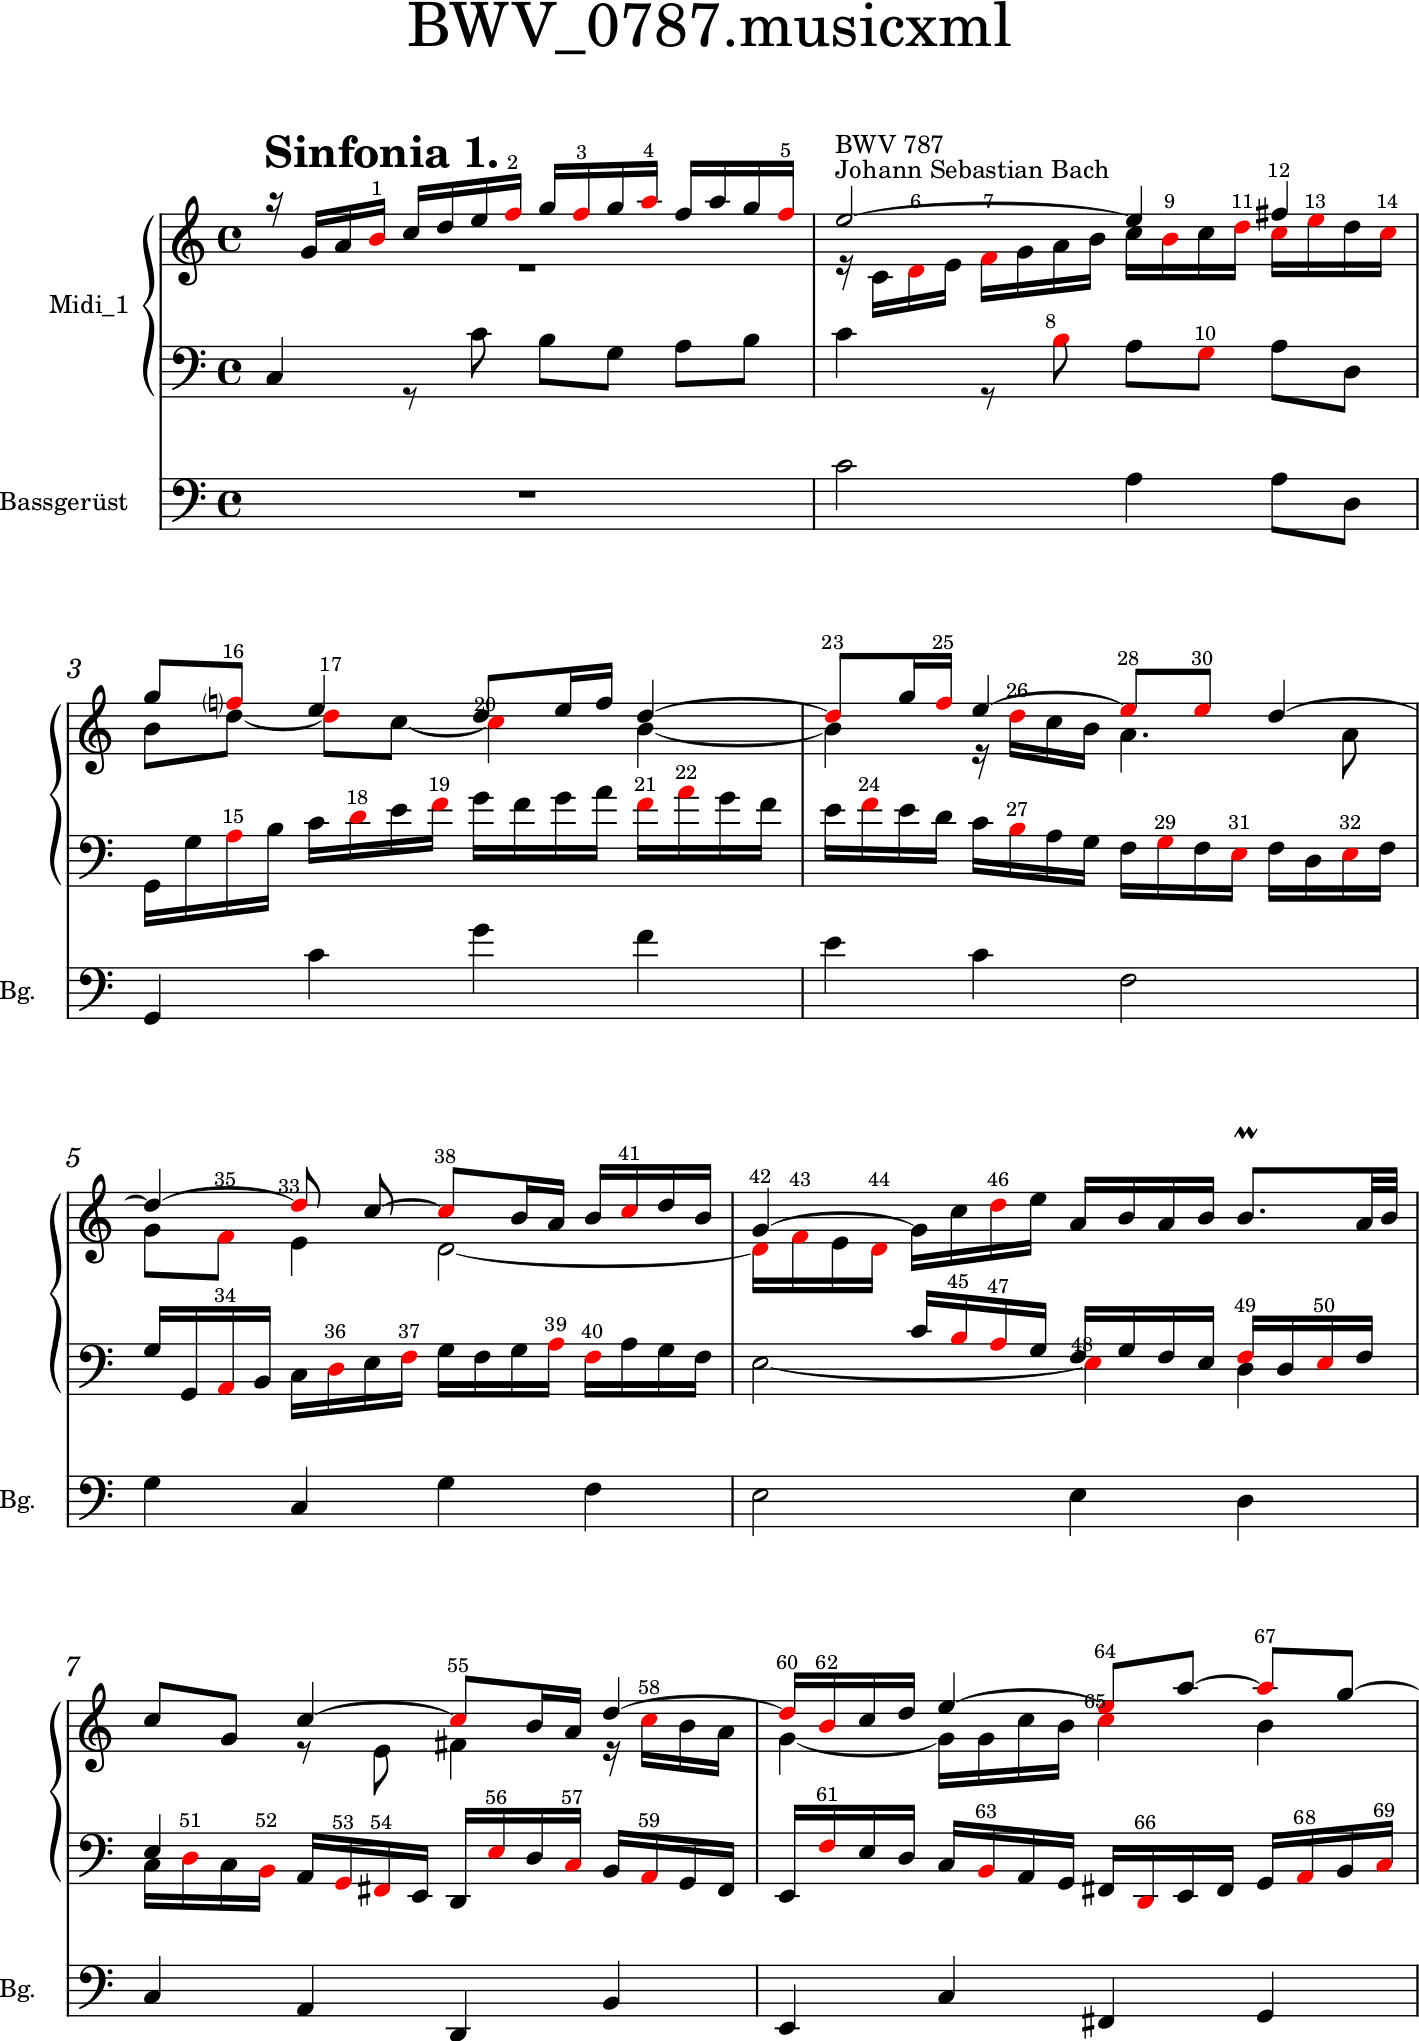

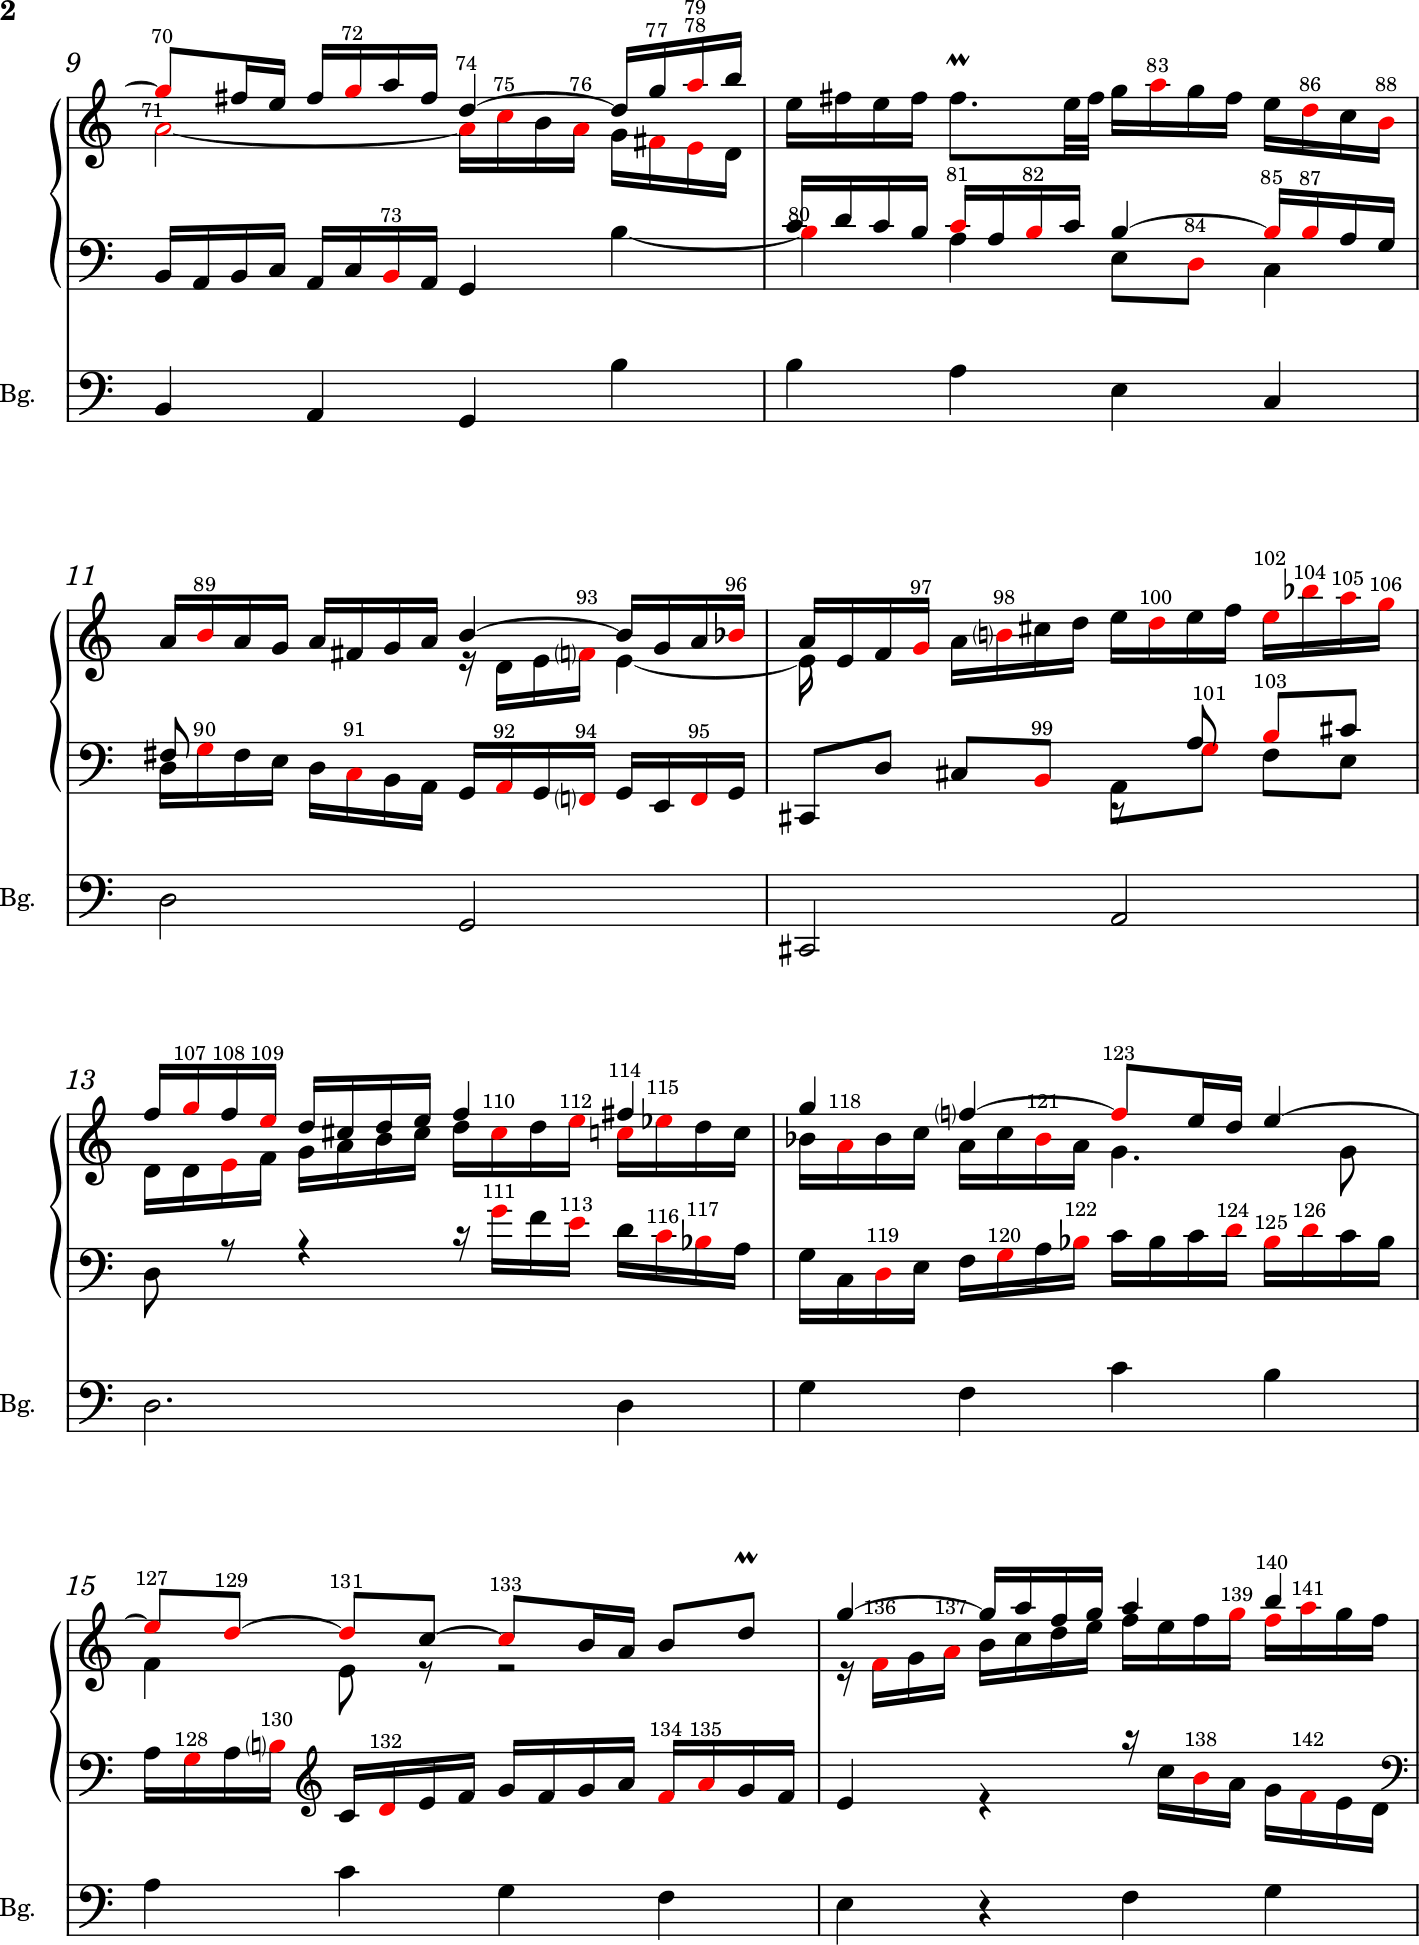

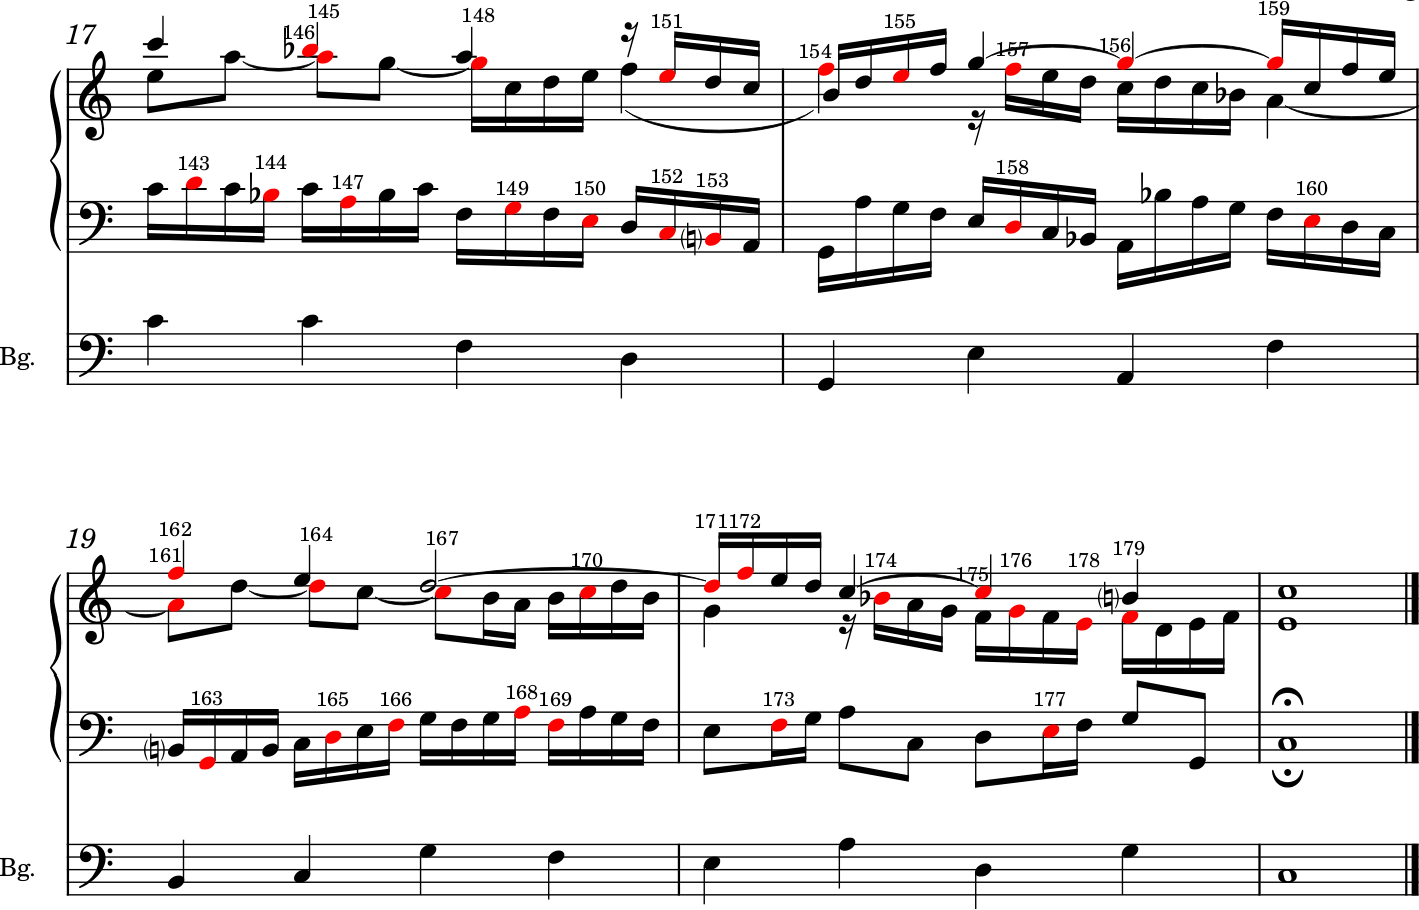

In [2]:
from music21 import converter

Dateipfad = r'C:\Users\Administrator\Desktop\1\Beethoven\BWV_0787.musicxml'
score = converter.parse(Dateipfad)

Dissonanzen = Dissonanzanalyse(score,0.0,hilfsstimme_index=-1)

# Danach Ereignisse in Markierungs-Schema umwandeln
markierungen = Markierungen_der_Ereignissen(Dissonanzen)

# Schließlich Markierungen auf die Partitur anwenden
Einfuegung_der_Markierungen(markierungen, score=score)

score.show()
output_path = r'C:\Users\Administrator\Desktop\1\ErgebnisProbe1.musicxml'
#score.write('musicxml', fp=output_path)

In [3]:
#Probe
print(Dissonanzen[4])

{'Nummer': '5', 'Takt': 1, 'Modus': 'Standard', 'Dissonanz': 'F5', 'PartnerTon': 'B3', 'Dissonanz_Offset': 3.75, 'Dissonanz_Beginn': None, 'Intervall': 'd5 - M3', 'offset_imTakt_Dissonanz': 3.75, 'offset_imTakt_Partnerton': 3.5, 'Anfang': 3.75, 'SliceAnfang': 3.75, 'SliceEnde': 4.0, 'untererTon': 'B3', 'ObererTon': 'F5', 'SliceBass': <music21.note.Note B>, 'Dissonanz_Objekt': <music21.note.Note F>, 'PartnerTon_Objekt': <music21.note.Note B>, 'Objekt': <music21.note.Note F>}


In [4]:
from music21 import chord, stream

# 1) Vorverarbeitung: chordify ohne Hilfsstimme
Stimmen = list(score.parts)
OriginalStimmen = stream.Score()
for p in Stimmen[:-1]:   # alle Parts außer der Hilfsstimme 
    OriginalStimmen.append(p)

Partitur_chordify = OriginalStimmen.chordify()
Entfaltung_derPartitur_chodify = Partitur_chordify.flatten()
SliceAnfang_Chordify = {float(c.offset): c for c in Entfaltung_derPartitur_chodify.getElementsByClass(chord.Chord)}

nachschlage_cache = {}  # start -> (akkord_obj, nach_Töne_mitOktavelage)

def baue_lookup_fuer_akkord(ch):
    """Gibt ein Mapping nameWithOctave -> [Noten] zurück; unterstützt gleichnamige Mehrfachnoten."""
    nach_Töne_mitOktavelage = {}
    for n in ch.notes:
        nach_Töne_mitOktavelage.setdefault(n.nameWithOctave, []).append(n)
    return nach_Töne_mitOktavelage

def wähle_Note(nach_Töne_mitOktavelage, akkord, Zielnote):
    """
    Zuerst exakte Übereinstimmung über nameWithOctave;
    falls mehrfach oder nicht gefunden, dann nach kleinstem MIDI-Abstand.
    """
    if Zielnote is None:
        return None
    lst = nach_Töne_mitOktavelage.get(Zielnote)
    if lst:
        return lst[0] if len(lst) == 1 else min(lst, key=lambda n: abs(n.pitch.midi - Zielnote.pitch.midi))
    # Fallback: allgemein nächste Note suchen (meist bei Notationsabweichungen)
    return min(akkord.notes, key=lambda n: (abs(n.pitch.midi - Zielnote.pitch.midi), n.pitch.midi))

TOL = 1e-6
def binde_von_note(n):
    """
    Bevorzugt editoriale Tie-Infos aus Ursprungsspur;
    sonst note.tie (meist nach chordify = None).
    """
    if n is None:
        return None
    t = None
    if hasattr(n, 'editorial') and hasattr(n.editorial, 'misc'):
        t = n.editorial.misc.get('tieTypeFromOrigin')
    return t if t is not None else (n.tie.type if n.tie else None)

for ev in Dissonanzen:
    start = float(ev['SliceAnfang'])
    Offset_Dissonanz = ev['offset_imTakt_Dissonanz']
    Offset_Partnerton  = ev['offset_imTakt_Partnerton']
    akkord, nach_Töne_mitOktavelage = nachschlage_cache.get(start, (None, None))
    if akkord is None:
        akkord = SliceAnfang_Chordify.get(start)
        if akkord is None:
            continue
        nach_Töne_mitOktavelage = baue_lookup_fuer_akkord(akkord)
        nachschlage_cache[start] = (akkord, nach_Töne_mitOktavelage)

    # Exakte/robuste Zuordnung unten & oben
    n1 = wähle_Note(nach_Töne_mitOktavelage, akkord, ev.get('Dissonanz_Objekt'))
    n2  = wähle_Note(nach_Töne_mitOktavelage, akkord, ev.get('PartnerTon_Objekt'))

    Bogen1 = binde_von_note(n1)
    Bogen2 = binde_von_note(n2)

    # neue Logik:
    # 1) Wenn irgendeine Note 'stop' oder 'continue' hat => Kollision = 4 (wie bisher bevorzugt)
    if any(s in ('stop', 'continue') for s in (Bogen1, Bogen2)):
        ev['Kollision'] = 'Ohne' 
    else:
        if Offset_Dissonanz is not None and Offset_Partnerton is not None and abs(Offset_Dissonanz - Offset_Partnerton) <= TOL:
            ev['Kollision'] = 'Mit' 
        else:
            ev['Kollision'] = 'Ohne'

In [5]:
from RhytmischeAnalyse import Bestimme_betontePosition

betonte_Positionen, zweite_betonte_Positionen= Bestimme_betontePosition(score)
# Beispielstruktur: {1: [0.0, 1.0], 2: [0.0, 1.0], ...}

# 2. Jede Ereignisse im passenden Takt mit den betonten Positionen vergleichen
for Ereignisse in Dissonanzen:
    Dissonanz = Ereignisse.get('Dissonanz_Objekt')
    Takt = Ereignisse.get('Takt')
    beginn = Ereignisse.get('Dissonanz_Beginn')
    offset = Dissonanz.offset_Takt + (beginn - Ereignisse['Dissonanz_Offset'] if beginn is not None else 0.0)
    Nummer=Ereignisse.get('Nummer')
    # Betonte Zeiten für genau diesen Takt:
    alle_betonte_Zeiten = betonte_Positionen.get(Takt, [])
    alle_zweite_betonte_Zeiten = zweite_betonte_Positionen.get(Takt, [])
    # Debug-Ausgabe (optional)
    #print(f"Takt {Takt}, betonte Positionen: {alle_betonte_Zeiten}")
    

    if offset in alle_betonte_Zeiten:
        Ereignisse['Position'] = 'betont'
    elif offset in alle_zweite_betonte_Zeiten:
        Ereignisse['Position'] = 'halb-betont'
    else:
        Ereignisse['Position'] = 'unbetont'
    Taktzeit=Ereignisse.get('Position')
    #print(f"Nummer:{Nummer},Ereignisse-Offset: {offset},Taktzeit: {Taktzeit}")

In [6]:
#from Bestimmung_KonsonanterSatz import _find_slice_index


def klingende_Noten_ohne_unterste(score: stream.Score, start, ende):
    out = []
    top = list(score.getElementsByClass([stream.Part, stream.PartStaff]))
    for obj in top[:-1]:  #Hilfsstimme weglassen
        out.extend(klingende_Noten_im_Bereich(obj, start, ende))
    return out

    
Grenz = Grenzen_aller_Elemente(score)
"""
    Ergänzt jedes Ereignis um ev['Vorbereitung'] gemäß:
      - 'Prime'                  (vorheriger Slice enthält selben Ton wie Später)
      - 'Sekunde Absteigende'    (vorheriger Slice enthält Ton eine Sekunde ÜBER Später)
      - 'Sekunde Aufsteigende'   (vorheriger Slice enthält Ton eine Sekunde UNTER Später)
      - 'Sprung'                 (ansonsten)

    Die Prüfung geschieht über alle Töne des vorherigen Slices (gesamte Partitur).
"""


# kleines Helferlein, um den Index des Slices zu finden
def _find_slice_index(t0: float) -> int | None:
    for i, g in enumerate(Grenz):
        if abs(float(g) - float(t0)) <= 0.0001:
            return i
    return None

for ev in Dissonanzen:
    Dissonanz: note.Note = ev.get('Dissonanz_Objekt')
    t0 = ev.get('Dissonanz_Offset')
    ev['Vorbereitung'] = None  # default

    if Dissonanz is None or t0 is None:
        continue

    idx = _find_slice_index(float(t0))
    if idx is None or idx == 0:
        # Es gibt keinen vorherigen Slice -> keine Vorbereitung bestimmbar
        continue

    Anfang_Slice_davor = float(Grenz[idx - 1])
    Ende_Slice_davor   = float(Grenz[idx])
    Noten_imSlice_davor = klingende_Noten_ohne_unterste(score, Anfang_Slice_davor, Ende_Slice_davor)

    # (1) Prime – gleicher Ton (inkl. Oktave)
    Primeeinführung = any(
        getattr(n, 'nameWithOctave', None) == Dissonanz.nameWithOctave
        for n in Noten_imSlice_davor
        if isinstance(n, note.Note)
    )
    # print(Anfang_Slice_davor,Ende_Slice_davor,Noten_imSlice_davor)

    # (2) Sekunde (diatonisch) – Richtung bestimmen
    # Wir prüfen diatonisch via interval.Interval, Richtung über MIDI
    sekunde_absteigend = False  # vorheriger Ton ist eine Sekunde ÜBER Dissonanz -> Bewegung in Dissonanz ist absteigend
    sekunde_aufsteigend = False # vorheriger Ton ist eine Sekunde UNTER Dissonanz -> Bewegung in Dissonanz ist aufsteigend
    chromatischer_Aufstieg = False
    chromatischer_Abstieg = False
    for Dissonanz in Noten_imSlice_davor:
        if not isinstance(Dissonanz, note.Note):
            continue
        try:
            iv = interval.Interval(Dissonanz, Dissonanz)
            if iv.generic and iv.generic.undirected == 2:
                if Dissonanz.pitch.midi > Dissonanz.pitch.midi:
                    sekunde_absteigend = True
                elif Dissonanz.pitch.midi < Dissonanz.pitch.midi:
                    sekunde_aufsteigend = True
        except Exception:
            pass
        if Dissonanz.step == Dissonanz.step and abs(Dissonanz.pitch.midi - Dissonanz.pitch.midi) == 1:
            if Dissonanz.pitch.midi >= Dissonanz.pitch.midi:
                chromatischer_Aufstieg = True
            else:
                chromatischer_Abstieg = True


    if (sekunde_aufsteigend + sekunde_absteigend + Primeeinführung+chromatischer_Aufstieg+chromatischer_Abstieg) >= 2:
        ev['Vorbereitung'] = '!brauche_Überprüfung'
    elif chromatischer_Aufstieg:
        ev['Vorbereitung'] = 'chromatischer Aufstieg'
    elif chromatischer_Abstieg:
        ev['Vorbereitung'] = 'chromatischer Abstieg'
    elif sekunde_absteigend:
        ev['Vorbereitung'] = 'absteigende Sekunde'
    elif sekunde_aufsteigend:
        ev['Vorbereitung'] = 'aufsteigende Sekunde'
    elif Primeeinführung:
        ev['Vorbereitung'] = 'Prime'
    # (3) kein Treffer -> Sprung
    else:
        ev['Vorbereitung'] = 'Sprung'

In [7]:
from typing import List, Dict
from music21 import note, interval, stream
from Bestimmung_KonsonanterSatz import klingende_Noten_ohne_unterste

def Verlassensweise_der_Dissonanz(
    Ereignisse: List[Dict],
    Partitur: stream.Score
) -> List[Dict]:
    """
    Ergänzt jedes Ereignis um Dissonanz['Auflösung'] gemäß:
      - 'Prime'                  (vorheriger Slice enthält selben Ton wie Später)
      - 'Sekunde Absteigende'    (vorheriger Slice enthält Ton eine Sekunde ÜBER Später)
      - 'Sekunde Aufsteigende'   (vorheriger Slice enthält Ton eine Sekunde UNTER Später)
      - 'Sprung'                 (ansonsten)

    Die Prüfung geschieht über alle Töne des vorherigen Slices (gesamte Partitur).
    """


    for ev in Ereignisse:
        Dissonanz: note.Note = ev.get('Dissonanz_Objekt')
        Offset=ev.get('Dissonanz_Offset')
        dissonanz_dauer = float(getattr(Dissonanz, 'quarterLength', 0.0))

        Slice_der_Auflösung = Offset + dissonanz_dauer
        Toene_in_der_Aufloesungsslice = klingende_Noten_ohne_unterste(Partitur,Slice_der_Auflösung)
        # 默认值
        ev['Auflösung'] = ev.get('Auflösung') or None
        #Testcode:print(Slice_der_Auflösung)
        
        #Testcode: print(start,Ende_der_Auflösungsslice,Toene_in_der_Aufloesungsslice)
        #Testcode: print(Toene_in_der_Aufloesungsslice)
       
        # --- (1) Prime – gleicher Ton (inkl. Oktave) ---
        Primeaufloesung = any(
            isinstance(n, note.Note) and getattr(n, 'nameWithOctave', None) == Dissonanz.nameWithOctave
            for n in Toene_in_der_Aufloesungsslice
        )

        # --- (2) Sekunde (diatonisch) – Richtung bestimmen ---
        sekunde_aufsteigend = False
        sekunde_absteigend = False
        sekunde_aufsteigend_typ = None   # 'm2' / 'M2' / 'A2'
        chromatischer_Aufstieg = False
        chromatischer_Abstieg = False
        for n in Toene_in_der_Aufloesungsslice:
            if not isinstance(n, note.Note):
                continue
            try:
                iv = interval.Interval(Dissonanz, n)
                # diatonisch zweite?
                if iv.generic and iv.generic.undirected == 2:
                    if n.pitch.midi > Dissonanz.pitch.midi:
                        sekunde_aufsteigend = True
                        st = abs(iv.semitones)
                        if st == 1:
                            sekunde_aufsteigend_typ = 'kleine_Sekunde'
                        elif st == 2:
                            sekunde_aufsteigend_typ = 'große_Sekunde'
                        elif st == 3:
                            sekunde_aufsteigend_typ = 'a2'
                    elif n.pitch.midi < Dissonanz.pitch.midi:
                        sekunde_absteigend = True
            except Exception:
                # 
                pass
            if n.step == Dissonanz.step and abs(n.pitch.midi - Dissonanz.pitch.midi) == 1:
                if Dissonanz.pitch.midi >= n.pitch.midi:
                    chromatischer_Abstieg = True
                else:
                    chromatischer_Aufstieg = True
        # 
        if (sekunde_aufsteigend + sekunde_absteigend + bool(Primeaufloesung)+chromatischer_Aufstieg+chromatischer_Abstieg) >= 2:
            ev['Auflösung'] = '!brauche_Überprüfung'
        elif sekunde_absteigend:
            ev['Auflösung'] = 'absteigender Schritt'
        elif chromatischer_Abstieg:
            ev['Auflösung'] = 'chromatischer Abstieg'
        elif sekunde_aufsteigend: 
            if sekunde_aufsteigend_typ == 'kleine_Sekunde':
                ev['Auflösung'] = 'aufsteigende kleine Sekunde'
            if sekunde_aufsteigend_typ == 'große_Sekunde':
                ev['Auflösung'] = 'aufsteigende große Sekunde'
        elif Primeaufloesung:
            ev['Auflösung'] = 'Prime'
        # (3) kein Treffer -> Sprung
        else:
            ev['Auflösung'] = 'Sprung'

    return Ereignisse

In [8]:
Dissonanzen = Verlassensweise_der_Dissonanz(Dissonanzen, score)
for d in Dissonanzen:
    print(f"DissonanzNr: {d.get('Nummer')},Takt: {d.get('Takt')}, Taktzeit: {d.get('Position')}, Anschlag:{d.get('Kollision')},Einführungsweise:{d.get('Vorbereitung')}, Verlassensweise:{d.get('Auflösung')},Intervall:{d.get('Intervall')}") 

DissonanzNr: 1,Takt: 1, Taktzeit: unbetont, Anschlag:Ohne,Einführungsweise:Sprung, Verlassensweise:aufsteigende kleine Sekunde,Intervall:M7 - ?
DissonanzNr: 2,Takt: 1, Taktzeit: unbetont, Anschlag:Ohne,Einführungsweise:Sprung, Verlassensweise:aufsteigende große Sekunde,Intervall:P4 - m6
DissonanzNr: 3,Takt: 1, Taktzeit: unbetont, Anschlag:Ohne,Einführungsweise:Sprung, Verlassensweise:aufsteigende große Sekunde,Intervall:d5 - P1
DissonanzNr: 4,Takt: 1, Taktzeit: unbetont, Anschlag:Ohne,Einführungsweise:Sprung, Verlassensweise:Sprung,Intervall:M9 - m6
DissonanzNr: 5,Takt: 1, Taktzeit: unbetont, Anschlag:Ohne,Einführungsweise:Sprung, Verlassensweise:absteigender Schritt,Intervall:d5 - M3
DissonanzNr: 6,Takt: 2, Taktzeit: halb-betont, Anschlag:Ohne,Einführungsweise:Sprung, Verlassensweise:!brauche_Überprüfung,Intervall:MM23:M2 - M3
DissonanzNr: 7,Takt: 2, Taktzeit: betont, Anschlag:Ohne,Einführungsweise:Sprung, Verlassensweise:aufsteigende große Sekunde,Intervall:P4 - M35
DissonanzNr: 8,Ta

In [9]:
import pandas as pd
from pathlib import Path
from openpyxl.styles import Font

def export_dissonanzen_to_excel(Dissonanzen, pfad=r"C:\Users\Administrator\Desktop\Dissonanzen.xlsx", sheet_name="Daten"):
  
    original_keys = ["Nummer", "Takt", "Position", "Kollision", "Vorbereitung", "Auflösung", "Intervall"]
    new_titles     = ["DissonanzNr", "Takt", "Taktzeit", "Anschlag", "Einführungsweise", "Verlassensweise", "Klang"]

    # 只保留需要的键
    filtered_data = [{key: d.get(key, "") for key in original_keys} for d in Dissonanzen]

    df = pd.DataFrame(filtered_data)
    df = df[original_keys]
    df.columns = new_titles

    pfad = Path(pfad)

    # 用 ExcelWriter 执行写入 + 样式修改
    with pd.ExcelWriter(pfad, engine="openpyxl") as writer:
        df.to_excel(writer, index=False, sheet_name=sheet_name)

        ws = writer.sheets[sheet_name]

        # 获取 “Einführungsweise” 列索引（Excel 从 1 开始计数）
        einf_col = new_titles.index("Einführungsweise") + 1
        Aufl_col = new_titles.index("Verlassensweise") + 1
        Inter_col=new_titles.index("Klang") + 1
        # 遍历每一行，判断是否要变红
        for row in range(2, len(df) + 2):
            for col in (einf_col, Aufl_col,Inter_col):
                cell = ws.cell(row=row, column=col)
                if str(cell.value).strip().startswith(("!", "?")):
                    cell.font = Font(color="FF0000")

Dissonanzen = Verlassensweise_der_Dissonanz(Dissonanzen, score)
#export_dissonanzen_to_excel(Dissonanzen, r"C:\Users\Administrator\Desktop\Dissonanzen_Beethoven.xlsx")
